# Objective
The goal of this task is to load, clean, and explore historical financial data
for TSLA, BND, and SPY in order to understand trends, volatility, stationarity,
and risk characteristics before building forecasting models.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf

from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import StandardScaler

plt.style.use("seaborn-v0_8")


In [10]:

tickers = ["TSLA", "BND", "SPY"]
start_date = "2015-01-01"
end_date = "2026-01-15"

dfs = []

for ticker in tickers:
    df = yf.download(
        ticker,
        start=start_date,
        end=end_date,
        auto_adjust=False,
        progress=False
    )
    df.reset_index(inplace=True)
    df["Ticker"] = ticker
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

# Sort for time-series correctness
df_all.sort_values(["Ticker", "Date"], inplace=True)

df_all.info()


<class 'pandas.DataFrame'>
Index: 8325 entries, 2775 to 2774
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype        
---  ------             --------------  -----        
 0   (Date, )           8325 non-null   datetime64[s]
 1   (Adj Close, TSLA)  2775 non-null   float64      
 2   (Close, TSLA)      2775 non-null   float64      
 3   (High, TSLA)       2775 non-null   float64      
 4   (Low, TSLA)        2775 non-null   float64      
 5   (Open, TSLA)       2775 non-null   float64      
 6   (Volume, TSLA)     2775 non-null   float64      
 7   (Ticker, )         8325 non-null   str          
 8   (Adj Close, BND)   2775 non-null   float64      
 9   (Close, BND)       2775 non-null   float64      
 10  (High, BND)        2775 non-null   float64      
 11  (Low, BND)         2775 non-null   float64      
 12  (Open, BND)        2775 non-null   float64      
 13  (Volume, BND)      2775 non-null   float64      
 14  (Adj Close, SPY)   2775 non-null   fl

d:\KAIM\weak-9\portfolio-optimization\.venv\Lib\site-packages\yfinance\scrapers\history.py:201: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
d:\KAIM\weak-9\portfolio-optimization\.venv\Lib\site-packages\yfinance\scrapers\history.py:201: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
d:\KAIM\weak-9\portfolio-optimization\.venv\Lib\site-packages\yfinance\scrapers\history.py:201: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()


In [11]:
# Flatten MultiIndex columns
df_all.columns = [
    col[0] if col[1] == "" else f"{col[0]}_{col[1]}"
    for col in df_all.columns
]

df_all.info()


<class 'pandas.DataFrame'>
Index: 8325 entries, 2775 to 2774
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype        
---  ------          --------------  -----        
 0   Date            8325 non-null   datetime64[s]
 1   Adj Close_TSLA  2775 non-null   float64      
 2   Close_TSLA      2775 non-null   float64      
 3   High_TSLA       2775 non-null   float64      
 4   Low_TSLA        2775 non-null   float64      
 5   Open_TSLA       2775 non-null   float64      
 6   Volume_TSLA     2775 non-null   float64      
 7   Ticker          8325 non-null   str          
 8   Adj Close_BND   2775 non-null   float64      
 9   Close_BND       2775 non-null   float64      
 10  High_BND        2775 non-null   float64      
 11  Low_BND         2775 non-null   float64      
 12  Open_BND        2775 non-null   float64      
 13  Volume_BND      2775 non-null   float64      
 14  Adj Close_SPY   2775 non-null   float64      
 15  Close_SPY       2775 non-null   fl

In [16]:
# Reshape Data into Long Format
price_cols = ["Open", "High", "Low", "Close", "Adj Close", "Volume"]
tickers = ["TSLA", "BND", "SPY"]

long_dfs = []

for ticker in tickers:
    cols = ["Date"] + [f"{c}_{ticker}" for c in price_cols]
    temp = df_all[cols].copy()
    temp.columns = ["Date"] + price_cols
    temp["Ticker"] = ticker
    long_dfs.append(temp)

df_clean = pd.concat(long_dfs, ignore_index=True)


In [17]:
df_clean = df_clean.dropna().reset_index(drop=True)
df_clean.info()


<class 'pandas.DataFrame'>
RangeIndex: 8325 entries, 0 to 8324
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype        
---  ------     --------------  -----        
 0   Date       8325 non-null   datetime64[s]
 1   Open       8325 non-null   float64      
 2   High       8325 non-null   float64      
 3   Low        8325 non-null   float64      
 4   Close      8325 non-null   float64      
 5   Adj Close  8325 non-null   float64      
 6   Volume     8325 non-null   float64      
 7   Ticker     8325 non-null   str          
dtypes: datetime64[s](1), float64(6), str(1)
memory usage: 520.4 KB


In [18]:
df_clean["Ticker"].value_counts()


Ticker
TSLA    2775
BND     2775
SPY     2775
Name: count, dtype: int64

In [19]:
df_all.isna().sum()


Date                 0
Adj Close_TSLA    5550
Close_TSLA        5550
High_TSLA         5550
Low_TSLA          5550
Open_TSLA         5550
Volume_TSLA       5550
Ticker               0
Adj Close_BND     5550
Close_BND         5550
High_BND          5550
Low_BND           5550
Open_BND          5550
Volume_BND        5550
Adj Close_SPY     5550
Close_SPY         5550
High_SPY          5550
Low_SPY           5550
Open_SPY          5550
Volume_SPY        5550
dtype: int64

In [20]:
# Sort values to ensure correct time-series order
df_clean = df_clean.sort_values(["Ticker", "Date"])


In [22]:
# Calculate daily percentage returns for each asset
# pct_change() computes (P_t - P_t-1) / P_t-1
df_clean["Daily_Return"] = (
    df_clean
    .groupby("Ticker")["Adj Close"]
    .pct_change()
)


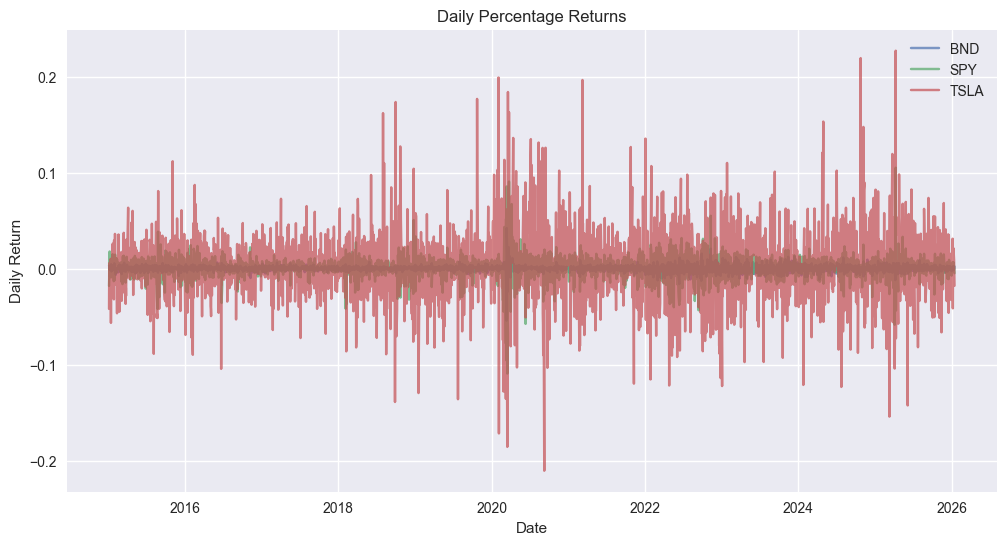

In [23]:

plt.figure(figsize=(12,6))

for ticker in df_clean["Ticker"].unique():
    subset = df_clean[df_clean["Ticker"] == ticker]
    plt.plot(subset["Date"], subset["Daily_Return"], label=ticker, alpha=0.7)

plt.title("Daily Percentage Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.legend()
plt.show()


- TSLA exhibits large spikes in daily returns, indicating high volatility
- BND shows very small fluctuations, confirming its low-risk profile
- SPY displays moderate volatility, consistent with broad market exposure


In [24]:
# Calculate rolling volatility using a 30-day window
# This captures short-term risk trends
df_clean["Rolling_30D_Volatility"] = (
    df_clean
    .groupby("Ticker")["Daily_Return"]
    .rolling(window=30)
    .std()
    .reset_index(level=0, drop=True)
)


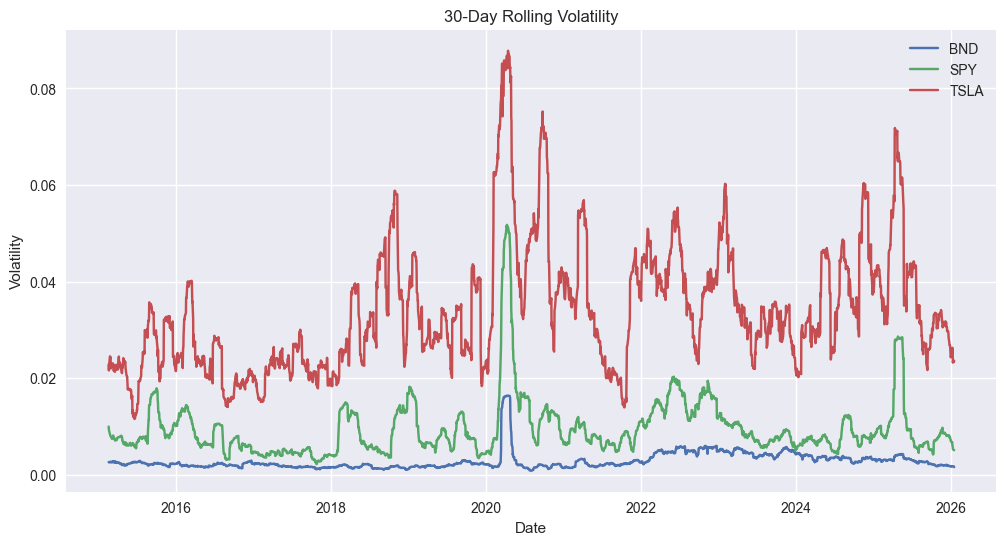

In [25]:
plt.figure(figsize=(12,6))

for ticker in df_clean["Ticker"].unique():
    subset = df_clean[df_clean["Ticker"] == ticker]
    plt.plot(
        subset["Date"],
        subset["Rolling_30D_Volatility"],
        label=ticker
    )

plt.title("30-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.show()


- Tesla (TSLA) consistently shows the highest rolling volatility
- Bond ETF (BND) remains stable with minimal risk
- SPY sits between TSLA and BND, offering balanced exposure


In [28]:
def adf_test(series, title=""):
    """
    Perform Augmented Dickey-Fuller test to check stationarity.
    
    H0 (null hypothesis): Series is non-stationary
    H1 (alternative hypothesis): Series is stationary
    """
    result = adfuller(series.dropna())
    
    print(f"ADF Test for {title}")
    print(f"ADF Statistic : {result[0]:.4f}")
    print(f"p-value       : {result[1]:.4f}")
    print("-" * 40)


In [29]:
# Test stationarity of price series (Adjusted Close)
for ticker in df_clean["Ticker"].unique():
    series = df_clean[df_clean["Ticker"] == ticker]["Adj Close"]
    adf_test(series, title=f"{ticker} Adjusted Close Price")


ADF Test for BND Adjusted Close Price
ADF Statistic : -1.0514
p-value       : 0.7341
----------------------------------------
ADF Test for SPY Adjusted Close Price
ADF Statistic : 1.1709
p-value       : 0.9958
----------------------------------------
ADF Test for TSLA Adjusted Close Price
ADF Statistic : -0.7802
p-value       : 0.8249
----------------------------------------


The ADF test results for adjusted closing prices show p-values greater than 0.05.
Therefore, we fail to reject the null hypothesis, indicating that price series
are non-stationary. This is expected for financial price data and confirms that
differencing is required before applying ARIMA models.


In [30]:
# Test stationarity of daily returns
for ticker in df_clean["Ticker"].unique():
    series = df_clean[df_clean["Ticker"] == ticker]["Daily_Return"]
    adf_test(series, title=f"{ticker} Daily Returns")


ADF Test for BND Daily Returns
ADF Statistic : -10.4338
p-value       : 0.0000
----------------------------------------
ADF Test for SPY Daily Returns
ADF Statistic : -17.2288
p-value       : 0.0000
----------------------------------------
ADF Test for TSLA Daily Returns
ADF Statistic : -53.0196
p-value       : 0.0000
----------------------------------------


The ADF test results for daily returns show p-values less than 0.05.
This means the null hypothesis is rejected and the return series
is stationary. This confirms that returns are suitable for
time-series modeling without additional differencing.


ARIMA models require stationary input data.
Since prices are non-stationary, differencing (the 'd' parameter in ARIMA)
will be required. Daily returns are already stationary, which makes them
appropriate for volatility modeling and risk analysis.


In [31]:
# Define threshold for extreme daily returns (±5%)
threshold = 0.05

# Identify outliers
outliers = df_clean[
    df_clean["Daily_Return"].abs() > threshold
]

outliers.head()


,Date,Open,High,Low,Close,Adj Close,Volume,Ticker,Daily_Return,Rolling_30D_Volatility
4081,2020-03-12,83.480003,84.889999,76.489998,80.330002,67.626488,16986900.0,BND,-0.054385,0.011161
6552,2018-12-26,235.970001,246.179993,233.759995,246.179993,221.397980,218485400.0,SPY,0.050525,0.016938
6853,2020-03-09,275.299988,284.190002,273.450012,274.230011,251.294342,309417300.0,SPY,-0.078094,0.023808
6854,2020-03-10,284.640015,288.519989,273.500000,288.420013,264.297546,276444100.0,SPY,0.051745,0.025921
6856,2020-03-12,256.000000,266.660004,247.679993,248.110001,227.358902,392220700.0,SPY,-0.095677,0.031644


In [32]:
outliers_count = (
    outliers
    .groupby("Ticker")["Daily_Return"]
    .count()
    .reset_index(name="Extreme_Days_Count")
)

outliers_count


,Ticker,Extreme_Days_Count
0,BND,1
1,SPY,15
2,TSLA,348


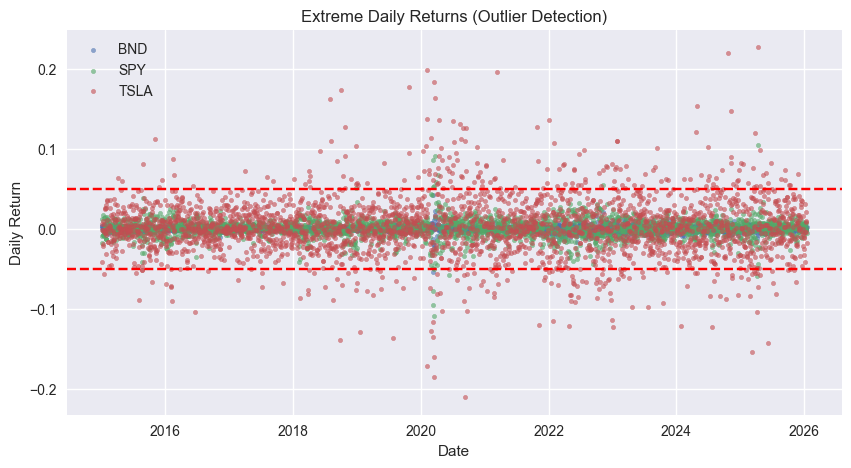

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for ticker in df_clean["Ticker"].unique():
    subset = df_clean[df_clean["Ticker"] == ticker]
    plt.scatter(
        subset["Date"],
        subset["Daily_Return"],
        label=ticker,
        s=10,
        alpha=0.6
    )

plt.axhline(threshold, color="red", linestyle="--")
plt.axhline(-threshold, color="red", linestyle="--")
plt.title("Extreme Daily Returns (Outlier Detection)")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.legend()
plt.show()


In [34]:
def calculate_var(returns, confidence_level=0.95):
    """
    Value at Risk (VaR) at a given confidence level.
    Represents the maximum expected loss under normal conditions.
    """
    return np.percentile(returns.dropna(), (1 - confidence_level) * 100)


def calculate_sharpe_ratio(returns, risk_free_rate=0.0):
    """
    Sharpe Ratio measures risk-adjusted return.
    Higher Sharpe Ratio = better risk-adjusted performance.
    """
    return (returns.mean() - risk_free_rate) / returns.std()


In [35]:
risk_metrics = []

for ticker in df_clean["Ticker"].unique():
    returns = df_clean[df_clean["Ticker"] == ticker]["Daily_Return"]
    
    risk_metrics.append({
        "Ticker": ticker,
        "VaR (95%)": calculate_var(returns),
        "Sharpe Ratio": calculate_sharpe_ratio(returns)
    })

risk_df = pd.DataFrame(risk_metrics)
risk_df


,Ticker,VaR (95%),Sharpe Ratio
0,BND,-0.004796,0.024030
1,SPY,-0.016719,0.050647
2,TSLA,-0.052529,0.051856


In [37]:
# Save cleaned dataset for future tasks
df_clean.to_csv("../data/processed/clean_prices.csv", index=False)


## Task 1 Summary

- Historical financial data for TSLA, BND, and SPY was extracted and cleaned
- Data was reshaped into a long-format structure suitable for time-series analysis
- Daily returns and rolling volatility were calculated
- Stationarity tests confirmed non-stationary prices and stationary returns
- Outlier analysis highlighted TSLA’s high volatility
- Risk metrics (VaR and Sharpe Ratio) quantified risk-return trade-offs

This analysis provides a solid foundation for forecasting and portfolio optimization.
